# [LAB-11] 시계열 분석ㅣ04-시계열의 통계적 접근(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 자기상관, 부분자기상관 계수 계산 
from statsmodels.tsa.stattools import acf, pacf

# 자기상관 그래프 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기 및 인덱스 설정 

In [2]:
origin = load_data('air_passengers')

# 1단원에서 만든 함수로 인덱스를 잡는다 
df = my_ts.set_index(origin, "Month", freq="MS")

print(f"데이터셋 크기: {df.shape[0]}행 | 인덱스 간격: {df.index.freqstr}")

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
데이터셋 크기: 144행 | 인덱스 간격: MS


### 3. 정상 시계열 만들기 
앞 단원들을 거치면서 얻은 결론(로그변환 + 1차차분 + 계절차분(12))을 적용 

In [4]:
# 정상 시계열로 변환 
stationary = my_ts.transform(df, "Passengers", log=True, 
                             diff=1, seasonal_diff=1, period=12)    

# 변환 결과에 대한 정상성 검정 
my_ts.adf_test(stationary)

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
Passengers,131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상


### 결과확인 
p-value = 0.0002로 정상서을 충족한다 

관측치는 144-> 131개로 줄었다. 

## # 자기상관의 이해 

하나의 변수와 그 변수 자신의 과거 사이의 상관 

일반적인 상관분석은 두 개의 다른 변수 사이의 관계를 본다.\
예: 키와 몸무게 

시계열에서는 하나의 변수와 그 변수 자신의 과거 사이의 관계를 본다. 

k를 시차lag라 한다\
k=1 이면 "이번 달과 지난달", k=12면 "이번달과 작년 같은 달"

비정상 시계열에서는 이 값이 아무 의미가 없다. -> 두 값이 함께 커지고 있다는 사실만 반영한다. 

## #02. 자기상관 Autocorrelation 의 이해 

### 1. 현재 데이터와 비교하기 위한 직전 데이터 준비 

pandas의 shift함수는 데이터를 한 칸씩 이동 시킨다. 

원본과 shift 결과를 비교하면 자신과 자신의 직전값을 비교할 수 잇다. 

In [6]:
# 원본 데이터를 한 칸씩 아래로 이동시킨다. "1, 2, 3" ---> "NaN, 1, 2"
# 음수를 부여하면 한 칸씩 위로 당긴다. "1, 2, 3" ---> "2, 3, NaN"   
origin_shift = df["Passengers"].shift(1)
or_shift = DataFrame({"원본": df["Passengers"],
                      "원본 shift": origin_shift})
display(or_shift.head(10))

# 정상 시계열을 한 칸씩 아래로 이동시킨다 
stationary_shift = stationary.shift(1)
st_shift = DataFrame({"정상 시계열": stationary, 
                      "정상 시계열 shift": stationary_shift})
display(st_shift.head(10))

,원본,원본 shift
Month,,
1949-01-01,112,NaN
1949-02-01,118,112.000
1949-03-01,132,118.000
1949-04-01,129,132.000
1949-05-01,121,129.000
1949-06-01,135,121.000
1949-07-01,148,135.000
1949-08-01,148,148.000
1949-09-01,136,148.000


,정상 시계열,정상 시계열 shift
Month,,
1950-02-01,0.039,NaN
1950-03-01,0.000,0.039
1950-04-01,-0.020,0.000
1950-05-01,-0.013,-0.020
1950-06-01,0.066,-0.013
1950-07-01,0.040,0.066
1950-08-01,0.000,0.040
1950-09-01,0.011,0.000
1950-10-01,-0.039,0.011


### 결과확인 


### 2. 지연 산점도 Lag Plot 시각화 

눈으로 자기상관의 형태를 확인한다.

현재 데이터 yt 를 세로축에, 직전 데이터 yt-1을 가로축에 놓고 산점도를 그리면 \
"직전 값이 현재 값을 얼마나 설명하는가"가 바로 보인다. 

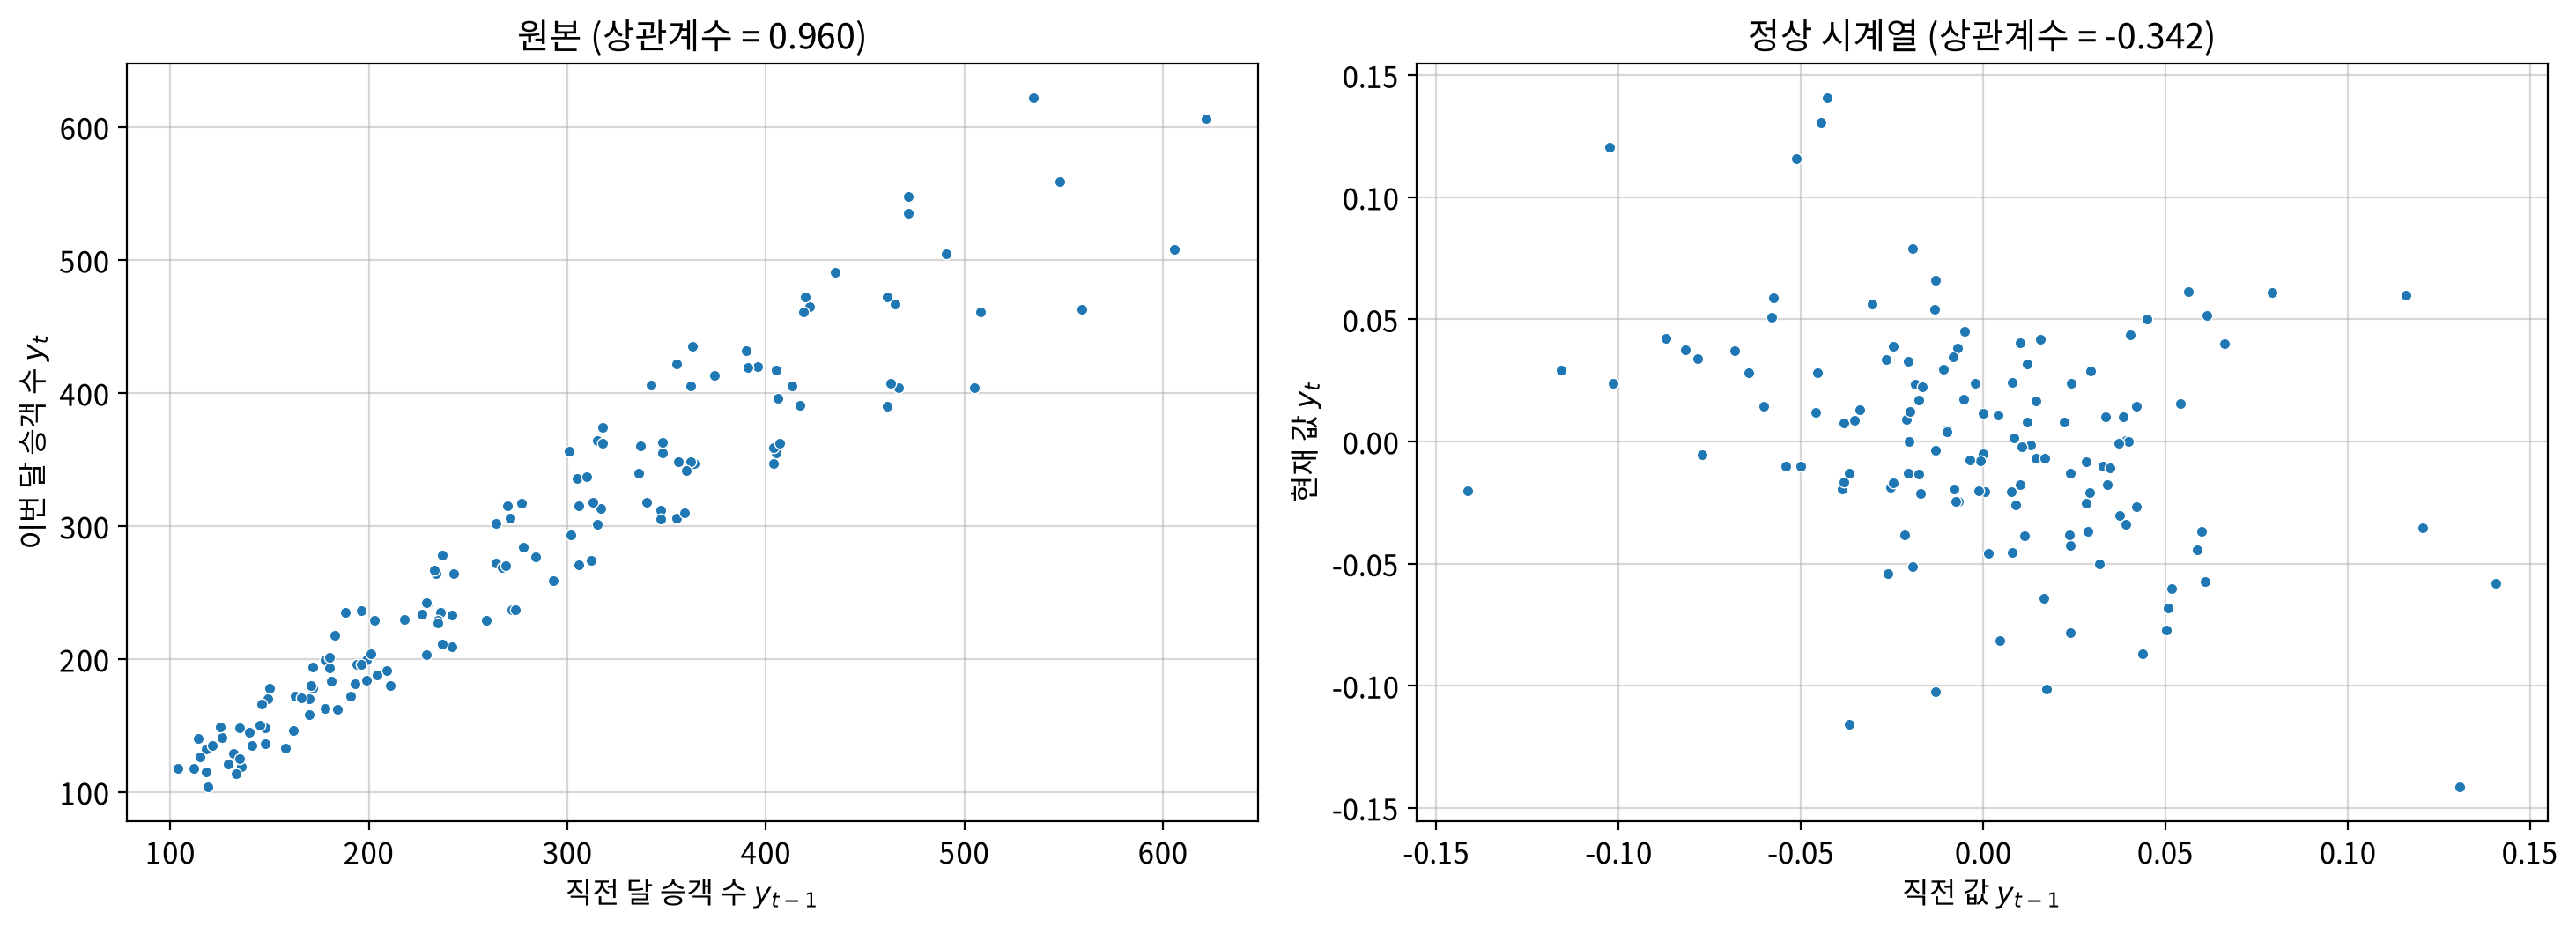

In [7]:
# 그래프 초기화 
fig, ax = my_plot.init(rows=1, cols=2, width=740, height=560)

# 원본 : 현재 값과 직전 값
my_plot.scatterplot(data=or_shift, x="원본 shift", y="원본", size=20, linewidth=0.5, ax=ax[0])  
ax[0].set_title(f"원본 (상관계수 = {df['Passengers'].corr(origin_shift):.3f})")
ax[0].set_xlabel("직전 달 승객 수 $y_{t-1}$")
ax[0].set_ylabel("이번 달 승객 수 $y_t$")   

# 정상 시계열 : 현재 값과 직전 값 
my_plot.scatterplot(data=st_shift, x="정상 시계열 shift", y="정상 시계열", size=20,
                    linewidth=0.5, ax=ax[1])
ax[1].set_title(f"정상 시계열 (상관계수 = {stationary.corr(stationary_shift):.3f})")    
ax[1].set_xlabel("직전 값 $y_{t-1}$")
ax[1].set_ylabel("현재 값 $y_t$")

my_plot.show()

### 결과확인 

원본 \
선형관계 

원본의 상관계수 0.960은 아무 의미가 없다. \
둘 다 계속 커지고 있기 때문에 자동으로 높게 나오는 것이다. 

정상 시계열 \
흩어진 구름 형태, 약한 우하향 

정상 시계열의 -0.342는 진짜 정보다. \
"지난 달에 많이 늘었으면 이번달은 덜 는다"는 되돌림 mean reversion 패턴을 뜻한다.

이것이 ACF/ PACF 를 정상 시계열에만 적용하는 이유다. 
비정상 시계열의 자기상관은 추세를 반영할 뿐, 모형에 쓸 정보를 주지 않는다. 

## # ACF 자기상관함수 의 이해 

시차 lag를 1,2,3....으로 바꿔가며 자기 상관을 전부 계산해 늘어놓은 그래프. 

"현재 값이 몇 시점 전까지 영향을 받는가"를 전반적으로 보여준다. 



### 1. ACF 시각화 

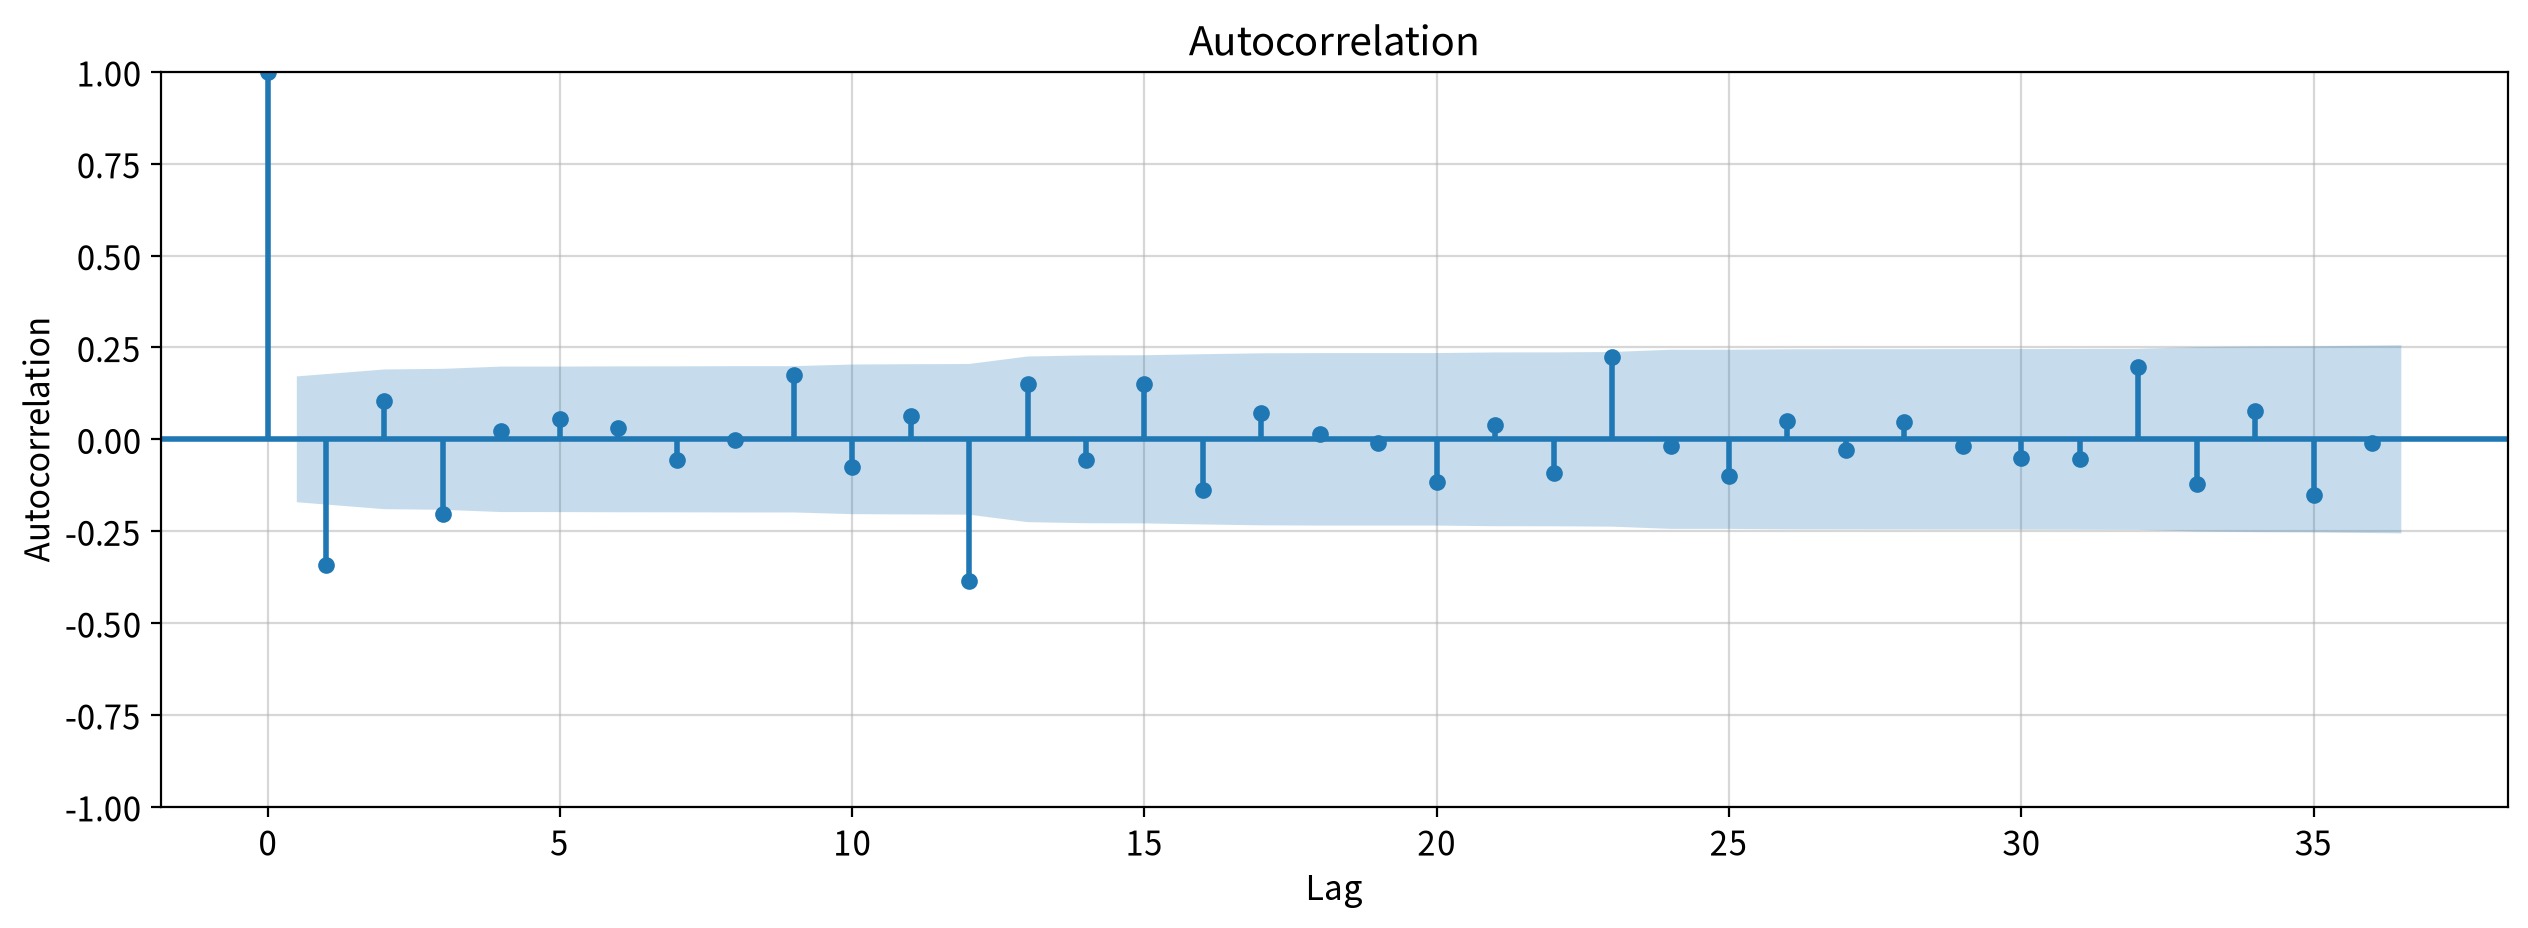

In [9]:
fig, ax = my_plot.init(rows=1, cols=1, width=1280, height=480)

# statsmodels의 plot_acf() 함수를 이용해 정상성 데이터의 자기상관 그래플르 그린다. 
plot_acf(stationary, lags=36, ax=ax) # lag를 계절주기의 3배로 설정함 
ax.set_xlabel("Lag") # x축은 차시(lag)를 의미함 
ax.set_ylabel("Autocorrelation") # y축은 자기상관계수를 의미함 

my_plot.show()

### 결과확인 

파란음영은 0이라고 봐도 되는 범위 -> 음영 바깥의 막대를 유의한 것으로 판정한다. 

막대가 음영 안에 있으면 그 시차가 자기상관은 통계적으로 0과 다르지 않다. 


처음 유의한 시차 lag 이후 파란 음영 안으로 들어가는 단절 지점을 찾는다 \
여기서는 2

단절 지점의 직전 시차인 1이 q값으로 확정된다. 

## # 자기 상관계수표에 의한 판독 

### ACF 시각화 결과의 판정을 돕는 통계량 도출 

### 2. 자기상관계수표 만들기 

In [11]:
LAGS = 36 # 확인할 최대 시차 (계절 주기 12의 3배)
N = len(stationary) # 관측치 수 
THRESHOLD = 2/ np.sqrt(N) # 유의성 기준값 
print(f"유의성 기준값: {THRESHOLD:.3f} (관측치 수 : {N})")

# lag 0은 자기 자신 (항상 1)이므로 판정 대상에서 잘라낸다
acf_values = acf(stationary, nlags=LAGS)[1:]    

# DataFrame 으로 변환 
acf_df = DataFrame({"lag": range(1, LAGS +1), "acf":acf_values.round(3)})   

# 계수의 절댓값이 기준값을 넘는 데이터인지 판별 (유의성 여부)
acf_df["유의성"] = np.abs(acf_values) > THRESHOLD
acf_df.T

유의성 기준값: 0.175 (관측치 수 : 131)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
lag,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
acf,-0.341,0.105,-0.202,0.021,0.056,0.031,-0.056,-0.001,0.176,-0.076,0.064,-0.387,0.152,-0.058,0.150,-0.139,0.070,0.016,-0.011,-0.117,0.039,-0.091,0.223,-0.018,-0.100,0.049,-0.030,0.047,-0.018,-0.051,-0.054,0.196,-0.122,0.078,-0.152,-0.010
유의성,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


### 3. 자기상관계수표 판독 

유의성이 처음으로 단절되는 지점을 찾는다 (없다면 전체 LAG 사용)\
첫 번째 단절 지점의 직전 지점의 lag 값이 우리가 찾는 q값이다. 

In [13]:
# 유의성이 단절되는 지점 중 첫 번째 지점의 인덱스 
fmin = acf_df[acf_df["유의성"] == False].index.min()

# 단절되는 시차가 없으면 전체 LAGS로 설정 
if np.isnan(fmin): fmin = LAGS

# q값 
print(f"유의성이 단절되는 시차: {acf_df.iloc[fmin-1]['lag']} (q값)")

# 전체 표에서 판정에 사용된 부분만 출려 ㄱ
acf_df[:fmin + 1]

유의성이 단절되는 시차: 1 (q값)


,lag,acf,유의성
0,1,-0.341,True
1,2,0.105,False


## # PACF 부분자기상관함수 

오늘과 그제 사이에 섞여 있는 "어제를 거친 간접 영향"을 걷어낸 것 

ACF 자기상관함수의 함정 \
오늘이 어제의 영향을 받고, 어제가 그제의 영향을 받는다면, \
그제가 오늘에 직접 영향을 주지 않았는데도 오늘과 그제 사이에 자동으로 상관이 생긴다 \
-> 간접 경로 

PACF 부분자기상관함수 \
어제를 고정해 놓고 그제가 오늘과 관계 있는지 판단 -> 직접 경로만 확인 

## #04. PACF 부분자기상관함수 Partial Auto Correlation 

### 1. PACF 시각화 
해석방법은 ACF 그래프와 동일하다 

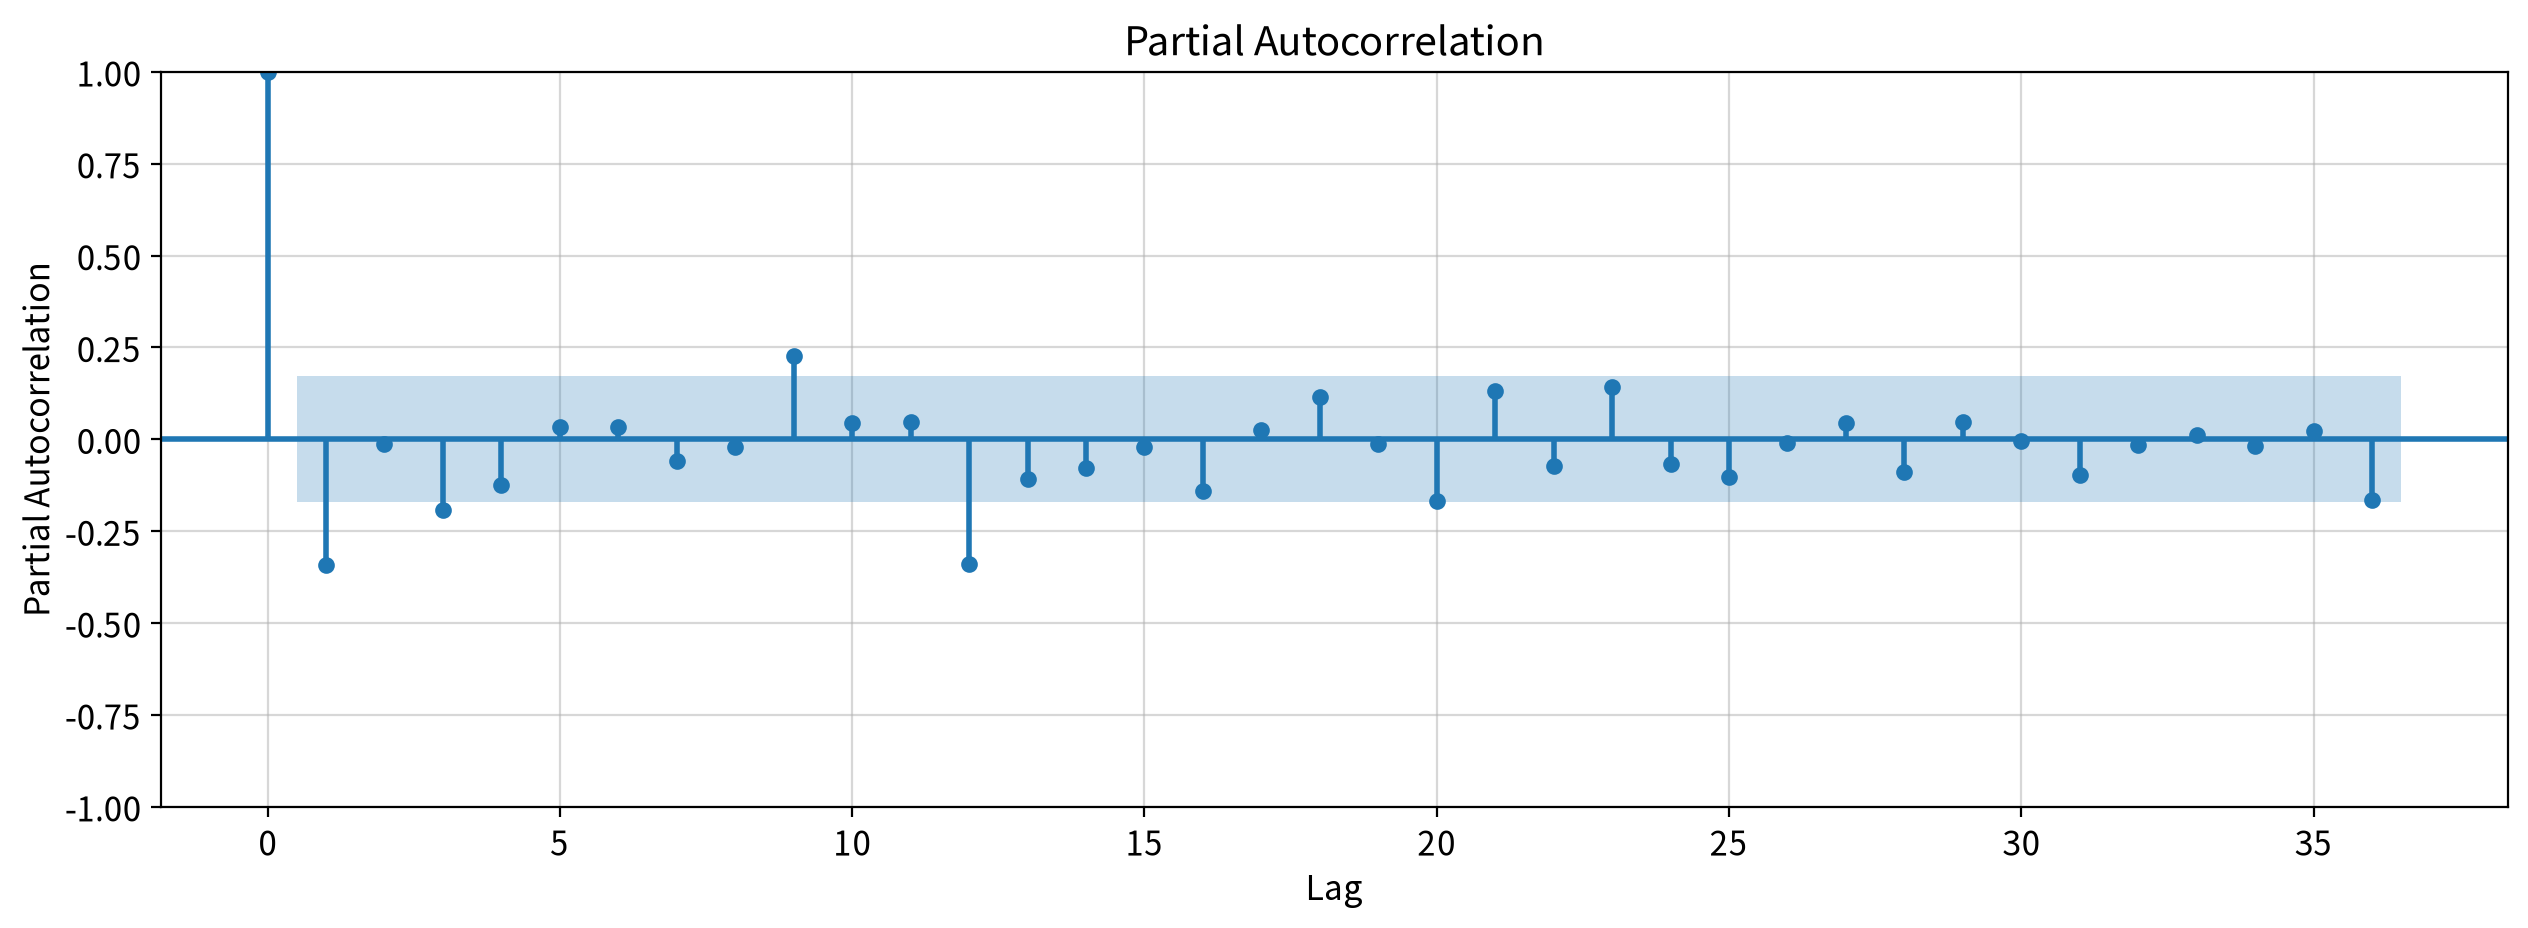

In [14]:
fig, ax = my_plot.init(rows=1, cols=1, width=1280, height=480)

# statsmodels의 plot_pacf() 함수를 이용해 정상성 데이터의 부분자기상관 그래프를 그린다. 
plot_pacf(stationary, lags=36, ax=ax)
ax.set_xlabel("Lag") # x축은 차시 lag를 의미함 
ax.set_ylabel("Partial Autocorrelation") # y축은 부분자기상관 

my_plot.show()

### 결과확인 

처음 유의한 시차 lag 이후에 파란 음영 안으로 들어가는 단절지점을 찾는다 \
여기서는 2 


단절 지점의 직전 시차인 1이 p값으로 확정된다. 

In [23]:
LAGS = 36 # 확인할 최대 시차 (계절 주기 12의 3배)
N = len(stationary) # 관측치 수 
THRESHOLD = 2/ np.sqrt(N) # 유의성 기준값 . PACF 표에서도 그대로 쓴다
print(f"유의성 기준값: {THRESHOLD:.3f} (관측치 수 : {N})")

# lag 0은 자기 자신 (항상 1)이므로 판정 대상에서 잘라낸다
pacf_values = pacf(stationary, nlags=LAGS)[1:]    

# DataFrame 으로 변환 
pacf_df = DataFrame({"lag": range(1, LAGS +1), "pacf":pacf_values.round(3)})   

# 계수의 절댓값이 기준값을 넘는 데이터인지 판별 (유의성 여부)
pacf_df["유의성"] = np.abs(pacf_values) > THRESHOLD

pacf_df.T

유의성 기준값: 0.175 (관측치 수 : 131)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
lag,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
pacf,-0.344,-0.013,-0.198,-0.130,0.034,0.036,-0.064,-0.022,0.244,0.048,0.051,-0.378,-0.127,-0.091,-0.022,-0.166,0.030,0.144,-0.005,-0.211,0.162,-0.088,0.190,-0.106,-0.132,-0.017,0.074,-0.138,0.070,-0.017,-0.120,-0.027,0.021,-0.037,0.047,-0.271
유의성,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


### 3. 부분자기상관계수표 판독 

acf() 판독과 동일한 방법을 사용한다. 

In [24]:
# 유의성이 단절되는 지점 중 첫번째 지점의 인덱스 
fmin = pacf_df[pacf_df["유의성"] == False].index.min()

# 단절되는 시차가 없으면 전체 LAGS로 설정 
if np.isnan(fmin): fmin = LAGS 

# p값
print(f"유의성이 단절되는 시차: {pacf_df.iloc[fmin-1]['lag']} (p값)")

# 전체 표에서 판정에 사용된 부분만 출력 
pacf_df[:fmin +1]

유의성이 단절되는 시차: 1 (p값)


,lag,pacf,유의성
0,1,-0.344,True
1,2,-0.013,False


## # AR과 MA는 서로 다른 흔적을 남긴다 

하나만 봐서는 AR인지 MA인지 알 수 없다. 두 그래프를 짝지어 봐야 판정된다. 



## # 계절 차수 P, Q 도출 

계절 시차로 P, Q 차수 판정하기 

### 1. 판정 대상 계절 시차 추리기 

계절 시차는 주기의 배수 (12, 24, 36)뿐이다. 그 사이의 시차는 P, Q 판정에 쓰지 않는다. 

단, #03 에서 정한 상한 관측치 수 /4 = 32.8을 넘는 36은 제외한다.\
뒤쪽 시차일 수록 계산에 쓰이는 쌍이 줄어 값을 믿을 수 없기 때문이다. 

In [25]:
PERIOD =12 # 계절주기 (1~3단원에서 확정)
LIMIT = N// 4 # 판정 상한 

# 계절 주기의 배수 중 상한 이내인 시차만 판정 대상으로 삼는다
season_lags = []

# 계절 주기 배수 시차 단위로 판정 상한까지 반복하여 판정 대상 시차를 구한다. 
for k in range(PERIOD, LAGS +1, PERIOD): 
    if k <= LIMIT:
        season_lags.append(k)

print(f"판정 상한: lag {LIMIT} | 판정 대상 계절 시차 : {season_lags}")

판정 상한: lag 32 | 판정 대상 계절 시차 : [12, 24]


### 2. 계절 시차의 계수만 모으기 

새로 계산할 것은 없다. 앞에서 만든 acf_df, pacf_df 에서 계절 시차 행만 뽑는다. \
유의성 기준값도 비계절 판정에 쓴 0.175를 그대로 쓴다. 
판정 기준은 시차가 아니라 관측치 수로 정해지기 때문이다. 

In [28]:
# lag를 인덱스로 바꾸면 원하는 시차의 행을 바로 꺼낼 수 있다. 
acf_idx = acf_df.set_index("lag")
pacf_idx = pacf_df.set_index("lag")

season_df = DataFrame({
    "lag": season_lags, 
    "주기 배수": [f"{k // PERIOD}배" for k in season_lags], 
    "acf": acf_idx.loc[season_lags, "acf"].values, 
    "acf 유의성": acf_idx.loc[season_lags, "유의성"].values, 
    "pacf": pacf_idx.loc[season_lags, "pacf"].values, 
    "pacf 유의성": pacf_idx.loc[season_lags, "유의성"].values,
})

season_df

,lag,주기 배수,acf,acf 유의성,pacf,pacf 유의성
0,12,1배,-0.387,True,-0.378,True
1,24,2배,-0.018,False,-0.106,False


### 3. 계절 차수 판정 

판정 규칙은 비계절과 똑같다. 단위만 1시차에서 1주기로 바뀐다. \
유의성이 처음으로 단절되는 지점을 찾고, 그 직전까지의 배수 개수가 곧 차수다 

In [29]:
# 유의성이 단절되는 지점 중 첫번째 지점의 인덱스 (앞 절과 같은 방법)
acf_break = season_df[season_df["acf 유의성"] == False].index.min()
pacf_break = season_df[season_df["pacf 유의성"] == False].index.min()

# 단절되는 지점이 없으면 마지막 배수까지 모두 유의한 것이다. 
if np.isnan(acf_break): acf_break = len(season_df)
if np.isnan(pacf_break): pacf_break = len(season_df)

# 인덱스는 0부터 시작하므로 단절 지점의 인덱스가 곧 "직전까지의 배수 개수"가 된다.
Q = int(acf_break) # 계절 ACF -> 계절 MA 차수
P = int(pacf_break) # 계절 PACF -> 계절 AR 차수 

print(f"계절 MA 차수 후보 (Q): {Q} < - 계절 ACF가 1배수 부터 연속으로 유의한 구간 {Q}개 ")  
print(f"계절 AR 차수 후보 (P): {P} < - 계절 PACF가 1배수 부터 연속으로 유의한 구간 {P}개 ")  



계절 MA 차수 후보 (Q): 1 < - 계절 ACF가 1배수 부터 연속으로 유의한 구간 1개 
계절 AR 차수 후보 (P): 1 < - 계절 PACF가 1배수 부터 연속으로 유의한 구간 1개 


# 2. 자기상관 판정 모듈화 